# Análisis de reseñas de **Skyscanner** en Trustpilot

**Sector:** Travel & Vacation · **Empresa objetivo:** `www.skyscanner.net` (100 reseñas)

Trabajo final del módulo de *Deep Learning · NLP*.

### Objetivos (rúbrica)
1. ¿La mayoría de las reseñas son positivas o negativas? ¿Y en la competencia?
2. ¿Qué *topics* tratan las reseñas? ¿Y la competencia?
3. Sentimiento por topic — ¿en qué somos mejores/peores que la competencia?
4. Identificar áreas de mejora.

### Decisiones metodológicas
- **No usamos `stars`** como label de sentimiento porque la columna está sesgada (imputada a la mediana de cada empresa). Aplicamos modelos de NLP.
- Comparamos **dos modelos de sentimiento**: `distilbert-sst-2` (binario) y `cardiffnlp/twitter-roberta-sentiment-latest` (positivo/neutro/negativo). El segundo es nuestro modelo de referencia por aportar el matiz neutral.
- Acotamos la competencia con **embeddings de `description`** (no toda la categoría Travel & Vacation, que mezcla aerolíneas, hoteles, alquileres y metabuscadores).
- **Topics**: `BERTopic` como modelo principal y `NMF + TF-IDF` como *sanity check* interpretable.
- **Limpieza con dos modos** — *soft* para sentimiento (preserva negaciones) y *hard* para topics (lowercase + stopwords + lematización).

## 1) Setup, imports y configuración

In [5]:
import os, re, warnings, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
except Exception:
    pass

In [ ]:
# ===== Configuración del análisis =====
DATA_PATH       = "trustpilot-reviews-123k.csv"
TARGET          = "www.skyscanner.net"
CATEGORY        = "Travel & Vacation"

# Modelos
SENT_BIN_MODEL  = "distilbert-base-uncased-finetuned-sst-2-english"
SENT_TRI_MODEL  = "cardiffnlp/twitter-roberta-base-sentiment-latest"
EMB_MODEL       = "sentence-transformers/all-MiniLM-L6-v2"

# Hiperparámetros
TOP_COMPETITORS = 15      # nº de competidores más cercanos a Skyscanner por description
N_TOPICS_NMF    = 8       # tópicos en el modelo NMF (baseline)
N_TOPICS_BERT   = 8       # K para BERTopic con KMeans (corpus muy homogéneo en vocabulario)
BERT_MIN_TOPIC  = 10      # min_cluster_size si quisiéramos volver a HDBSCAN density-based
BERT_NEIGHBORS  = 10      # n_neighbors de UMAP en BERTopic
BATCH_SENT      = 32
MIN_TOPIC_DOCS_SKY = 4    # umbral mínimo de reseñas de Skyscanner por topic para reportar comparativa, esto evita conclusiones basadas en muy pocas opiniones.

ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)
print("CWD:", Path.cwd())

CWD: C:\Users\juant\OneDrive\Desktop\Juan T\Desarrollo Profesional\Capacitación\Evolve\Proyectos Módulos\proyecto_deep_learning


## 2) Carga del dataset

In [ ]:
df_full = pd.read_csv(DATA_PATH)
print("Shape:", df_full.shape)
print("Columnas:", list(df_full.columns))
df_full.head(3)

Shape: (123181, 6)
Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Great quality dog drying robe although…,Great quality dog drying robe although had to wait a while for it to come back into stock,5
1,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Really prompt service,"Really prompt service, The sofa covers have not moved since being put on despite the efforts of three cocker spaniel...",5
2,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Life saver,I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little...,5


In [ ]:
print("Categorías únicas:", df_full["category"].nunique())
print("Empresas únicas:", df_full["company"].nunique())
print(f"Reseñas en categoría '{CATEGORY}':", (df_full['category']==CATEGORY).sum())
print(f"Reseñas de '{TARGET}':", (df_full['company']==TARGET).sum())

Categorías únicas: 22
Empresas únicas: 1680
Reseñas en categoría 'Travel & Vacation': 5425
Reseñas de 'www.skyscanner.net': 100


## 3) EDA inicial

Antes de cualquier modelado, miramos: distribución de la longitud de reseña, la columna `stars`
para confirmar el sesgo del dataset, y las empresas con muestra completa (100 reseñas) dentro
de Travel & Vacation, ya que de allí saldrá la competencia.

,review_len
count,123181.000000
mean,358.787305
std,314.553061
min,10.000000
25%,177.000000
50%,290.000000
75%,440.000000
max,9956.000000


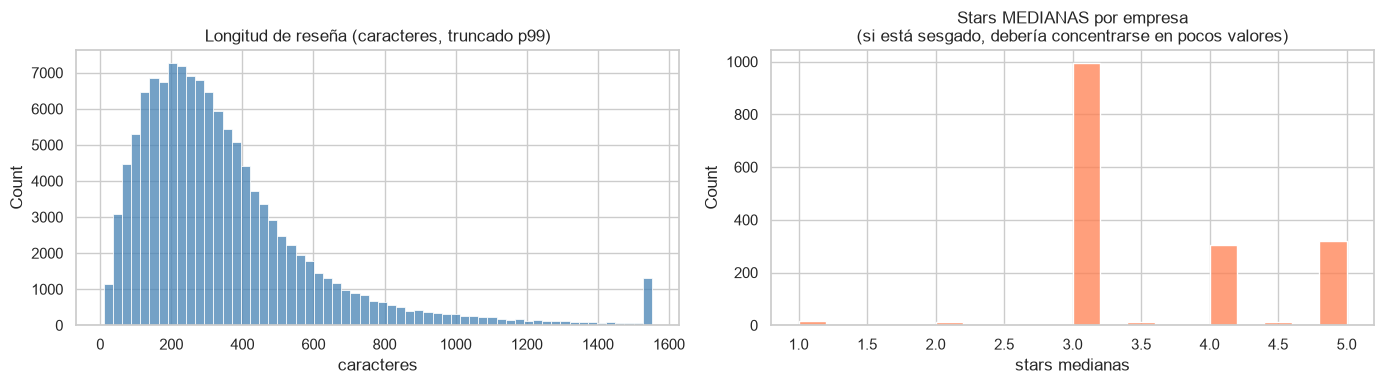

In [ ]:
df_full["review_len"] = df_full["review"].astype(str).str.len()
display(df_full["review_len"].describe().to_frame("review_len"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_full["review_len"].clip(upper=df_full["review_len"].quantile(0.99)),
             bins=60, color="steelblue", ax=axes[0])
axes[0].set_title("Longitud de reseña (caracteres, truncado p99)")
axes[0].set_xlabel("caracteres")

# Sesgo de 'stars' por empresa: estrellas medianas por compañía
star_med = df_full.groupby("company")["stars"].median()
sns.histplot(star_med, bins=20, color="coral", ax=axes[1])
axes[1].set_title("Stars MEDIANAS por empresa\n(si está sesgado, debería concentrarse en pocos valores)")
axes[1].set_xlabel("stars medianas")
plt.tight_layout(); plt.show()

In [ ]:
# Confirmamos el sesgo del dataset: la mediana de stars por empresa toma muy pocos valores.
print("Valores únicos de la mediana de stars por empresa:")
print(star_med.value_counts().sort_index())

Valores únicos de la mediana de stars por empresa:
stars
1.0     18
2.0     14
2.5      4
3.0    995
3.5     13
4.0    304
4.5     12
5.0    320
Name: count, dtype: int64


In [ ]:
# Foco en Travel & Vacation
df_cat = df_full[df_full["category"] == CATEGORY].copy()
print(f"Total reseñas en {CATEGORY}: {len(df_cat):,}")
print(f"Empresas distintas: {df_cat['company'].nunique()}")

reviews_per_comp = df_cat["company"].value_counts()
print("\nEmpresas con 100 reseñas (muestra completa):", (reviews_per_comp == 100).sum())

print("\nTop 10 empresas por nº de reseñas:")
print(reviews_per_comp.head(10).to_string())

Total reseñas en Travel & Vacation: 5,425
Empresas distintas: 57

Empresas con 100 reseñas (muestra completa): 37

Top 10 empresas por nº de reseñas:
company
www.villaplus.com           100
www.hoseasons.co.uk         100
www.sykescottages.co.uk     100
cottages.com                100
holidaycottages.co.uk       100
www.jet2holidays.com        100
www.crystaltravel.co.uk     100
www.easyjet.com             100
www.lastminute.com          100
www.barrheadtravel.co.uk    100


## 4) Inspección de caracteres y función de limpieza

Antes de limpiar, miramos qué *ruido* hay en las reseñas: URLs, HTML, emojis, dobles espacios,
`\n` literal, signos de puntuación raros, etc. Eso guía la función de limpieza.

Vamos a definir **dos modos**:

- `clean_soft` — para **sentimiento**. Conserva negaciones (`no`, `not`, `never`, `don't`,
  `wouldn't`), signos básicos y mayúsculas/minúsculas tal cual, porque los transformers
  manejan estos casos internamente y la negación es crítica para detectar reseñas negativas.
- `clean_hard` — para **topics y wordclouds**. Lowercase + remove stopwords + lemmatización
  + eliminación de tokens muy cortos / de nombres propios obvios (Skyscanner, etc) para
  evitar que el nombre de la marca domine los topics.

In [ ]:
# Vistazo a una muestra del ruido del texto
samples = df_cat.sample(8, random_state=SEED)["review"].tolist()
for s in samples:
    print("·", repr(s[:160]))

· 'It was a super lovely apartment with a huge balcony around the building. The bathroom was perfect, and the whole apartment was spotless and really well-decorate'
· 'not given full details recently on stay in scotland. Road closed so long detour to reach hotel....no signs !!Restaurant closed. Not informed before arriving .'
· 'Overall 4. The park is AMAZING! The only thing that lets it down is the expensive and tasteless food and the expensive drinks at Aubrey’s. Other than that the p'
· 'Quite disappointed so far...checked in and asked about booking leisure facilities and were told to go to pool and book, fully booked for our stay and told we ne'
· "Avoid, overcharged my flights by 1.6k and wouldn't help on arrival at hotel. SCAMMED me into thinking I'd booked a holiday for 4 with breakfast but was only 2 a"
· 'Elsa was helpful and professional and very patient '
· 'Cancelled the car I booked with them twice. They are advertising cars as available at a good price, then after you hav

In [ ]:
# Diagnóstico de patrones que vale la pena limpiar
patterns = {
    "url":        r"https?://\S+|www\.[\w./?=&%-]+",
    "email":      r"\b[\w.+-]+@\w+\.\w+\b",
    "newline_lit":r"\\n",
    "html_tag":   r"<[^>]+>",
    "html_entity":r"&[a-z]+;",
    "emoji":      r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF]",
    "multi_punct":r"[!?.]{3,}",
    "numeric":    r"\b\d+\b",
}
diag = {k: int(df_cat["review"].astype(str).str.contains(v, regex=True, na=False).sum()) for k, v in patterns.items()}
print("Reseñas de la categoría que matchean cada patrón (de {:,}):".format(len(df_cat)))
for k, v in diag.items():
    print(f"  {k:13s} {v:>5}")

Reseñas de la categoría que matchean cada patrón (de 5,425):
  url               1
  email             0
  newline_lit       0
  html_tag          0
  html_entity       0
  emoji           126
  multi_punct     362
  numeric        2176


In [ ]:
import nltk
from nltk.corpus import stopwords as nltk_stop
from nltk.stem import WordNetLemmatizer
try: nltk_stop.words("english")
except LookupError: nltk.download("stopwords", quiet=True)
try: WordNetLemmatizer().lemmatize("tests")
except LookupError: nltk.download("wordnet", quiet=True); nltk.download("omw-1.4", quiet=True)

# ---- Stopwords ----
# Para topics queremos sacarlas; para sentimiento solamente NO las sacamos porque la negación
# es crítica. Mantenemos en la lista 'hard' palabras como 'flight', 'hotel', etc. porque son
# semánticas (definen el topic). Quitamos en cambio nombres propios obvios.
EN_STOP = set(nltk_stop.words("english"))
NEG_KEEP = {"no", "not", "nor", "never", "none", "n't",
            "isn't","wasn't","aren't","weren't","don't","doesn't","didn't",
            "won't","wouldn't","can't","couldn't","shouldn't","cannot"}
EN_STOP_FOR_TOPICS = set(EN_STOP)                         # para topics SÍ quitamos todas las stopwords incluidas negaciones (no aportan al topic, sí al sentiment)
EXTRA_STOP_TOPICS = {
    # marca objetivo y dominios
    "skyscanner","sky","scanner","com","net","co","uk","www","https","http",
    # nombres de competidores que aparecen muy seguido y son ruido temático
    "audley","gosplitty","splitty","netflights","destinology","traveltrolley","trolley",
    "lastminute","travelzoo","easyjet","ryanair","loveholidays","budgetair","trip",
    "alternativeairlines","alternative","superescapes","escapes","holidaysplease",
    "flightoffice","wingly","crystaltravel","traveljunction","travelhouseuk",
    # nombres propios de agentes de servicio que ruidan los topics
    "ethan","dania","stephanie","jose","helen","obie","claire","jacqueline","adam",
    "steph","james","john","mark","emma","sarah","lucy","luca",
    # fillers genéricos
    "ll","ve","re","im","amp","th","st","nd","rd","yes","no","ok","okay",
    "thing","things","also","get","got","really","etc","one","two","go","went",
    "would","could","still","even","much","many","make","made","use","used","using",
    "website","site","app","application","time","day","days","today","yesterday","ago",
    "us","u","we","i","they","them","you","your","my","mine","our","their",
}
EN_STOP_FOR_TOPICS |= EXTRA_STOP_TOPICS

URL_RE   = re.compile(r"https?://\S+|www\.[\w./?=&%-]+", re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w.+-]+@\w+\.\w+\b")
HTML_RE  = re.compile(r"<[^>]+>")
HTML_ENT = re.compile(r"&[a-z]+;", re.IGNORECASE)
NLINE_RE = re.compile(r"\\n|\n|\r|\t")
MULTI_WS = re.compile(r"\s+")
EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")

def clean_soft(text: str) -> str:
    if not isinstance(text, str): return ""
    t = HTML_RE.sub(" ", text)
    t = HTML_ENT.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    t = NLINE_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = MULTI_WS.sub(" ", t).strip()
    return t

# Para topics: tokenización simple + filtrado
TOKEN_RE = re.compile(r"[A-Za-z][A-Za-z'-]{2,}")
_LEM = WordNetLemmatizer()
def clean_hard(text: str) -> str:
    soft = clean_soft(text).lower()
    toks = TOKEN_RE.findall(soft)
    out = []
    for tk in toks:
        if tk in EN_STOP_FOR_TOPICS: continue
        if len(tk) < 3: continue
        out.append(_LEM.lemmatize(tk))
    return " ".join(out)

# Demo en una reseña real
demo = df_cat[df_cat["company"]==TARGET]["review"].iloc[3]
print("Original :", demo[:180], "...\n")
print("Soft     :", clean_soft(demo)[:180], "...\n")
print("Hard     :", clean_hard(demo)[:180], "...")

Original : I can find cost-effective flights every time I use it, so I will use it whenever I go on a trip or take holiday. ...

Soft     : I can find cost-effective flights every time I use it, so I will use it whenever I go on a trip or take holiday. ...

Hard     : find cost-effective flight every whenever take holiday ...


## 5) Filtrado de competencia por embedding de `description`

La categoría Travel & Vacation incluye negocios muy distintos: metabuscadores, OTAs,
aerolíneas, alquileres de cottage, parques vacacionales. Para que la "competencia" tenga
sentido analítico, embebemos la `description` de cada empresa y nos quedamos con las
**N empresas más cercanas semánticamente** a Skyscanner.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Una descripción por empresa de la categoría
desc_by_company = (df_cat.groupby("company")["description"].first().fillna("").to_dict())
target_desc     = desc_by_company[TARGET]
print("Description de Skyscanner (excerpt):\n", target_desc[:300])

Description de Skyscanner (excerpt):
 Skyscanner is the world's travel search site, saving you time and money by finding the best travel options wherever you want to go. 
We are free and unbiased - over 80 million travellers around the world trust us each month to help them find the best flights, hotels and car hire. 

Our secret is in 


In [ ]:
emb_model = SentenceTransformer(EMB_MODEL)
companies = list(desc_by_company.keys())
desc_vecs = emb_model.encode([desc_by_company[c] for c in companies],
                             batch_size=64, convert_to_numpy=True, show_progress_bar=False)
target_vec = desc_vecs[companies.index(TARGET)].reshape(1, -1)
sims = cosine_similarity(target_vec, desc_vecs).ravel()

similarity_df = (pd.DataFrame({"company": companies, "similarity": sims,
                               "n_reviews": [int((df_cat['company']==c).sum()) for c in companies]})
                 .sort_values("similarity", ascending=False).reset_index(drop=True))
print("Top 20 empresas por similitud semántica con Skyscanner:\n")
display(similarity_df.head(20))

Top 20 empresas por similitud semántica con Skyscanner:



,company,similarity,n_reviews
0,www.skyscanner.net,1.000000,100
1,www.travelzoo.com,0.460580,100
2,www.netflights.com,0.458119,100
3,www.destinology.co.uk,0.436217,78
4,www.audleytravel.com,0.433928,100
5,trip.com,0.421676,100
6,traveltrolley.co.uk,0.398370,100
7,www.lastminute.com,0.397056,100
8,gosplitty.com,0.394434,91
9,flightoffice.co.uk,0.378258,87


In [ ]:
# Empresas más cercanas (excluyendo Skyscanner) con muestra de 100 reseñas
candidates = similarity_df[(similarity_df["company"] != TARGET) & (similarity_df["n_reviews"] >= 50)]
COMPETITORS = candidates.head(TOP_COMPETITORS)["company"].tolist()
print(f"Competidores seleccionados ({len(COMPETITORS)}):")
for c in COMPETITORS:
    sim = similarity_df.loc[similarity_df['company']==c,'similarity'].iat[0]
    print(f"  · {c:<35s}  sim={sim:.3f}")

Competidores seleccionados (15):
  · www.travelzoo.com                    sim=0.461
  · www.netflights.com                   sim=0.458
  · www.destinology.co.uk                sim=0.436
  · www.audleytravel.com                 sim=0.434
  · trip.com                             sim=0.422
  · traveltrolley.co.uk                  sim=0.398
  · www.lastminute.com                   sim=0.397
  · gosplitty.com                        sim=0.394
  · flightoffice.co.uk                   sim=0.378
  · www.alternativeairlines.com          sim=0.376
  · superescapes.co.uk                   sim=0.370
  · www.holidaysplease.co.uk             sim=0.369
  · loveholidays.com                     sim=0.360
  · www.easyjet.com                      sim=0.356
  · budgetair.co.uk                      sim=0.350


In [ ]:
# Dataset Skyscanner
df_sky = df_cat[df_cat["company"] == TARGET].copy().reset_index(drop=True)
df_sky["group"] = "Skyscanner"

# Dataset competencia
df_comp = df_cat[df_cat["company"].isin(COMPETITORS)].copy().reset_index(drop=True)
df_comp["group"] = "Competencia"

df_all = pd.concat([df_sky, df_comp], ignore_index=True)
print("Skyscanner: ", len(df_sky))
print("Competencia:", len(df_comp), f"({df_comp['company'].nunique()} empresas)")
print("Total:      ", len(df_all))

# Aplicamos limpieza
df_all["review_soft"] = df_all["review"].apply(clean_soft)
df_all["review_hard"] = df_all["review"].apply(clean_hard)
df_all["title_soft"]  = df_all["title"].astype(str).apply(clean_soft)

# Concat title + review para sentimiento (el título suele cargar mucho sentimiento)
df_all["text_sent"]   = (df_all["title_soft"] + ". " + df_all["review_soft"]).str.strip()
df_all["text_topic"]  = df_all["review_hard"]

# Quitamos reseñas vacías tras limpieza
mask_ok = df_all["text_sent"].str.split().str.len() >= 3
print("Reseñas demasiado cortas eliminadas:", (~mask_ok).sum())
df_all = df_all[mask_ok].reset_index(drop=True)
df_all.sample(3, random_state=SEED)[["group","company","title","stars","text_sent","text_topic"]]

Skyscanner:  100
Competencia: 1444 (15 empresas)
Total:       1544


Reseñas demasiado cortas eliminadas: 0


,group,company,title,stars,text_sent,text_topic
1494,Competencia,traveltrolley.co.uk,They responded quickly,3,They responded quickly. They responded quickly - I didn’t get a refund but was given a voucher in May when I was mea...,responded quickly refund given voucher may meant fly voucher expire contacted month november said wanted money back ...
543,Competencia,trip.com,Too rush for the booking pricess,3,Too rush for the booking pricess. I waa booking a flight one way from Hong Kong to Seattle to change plane in ICN So...,waa booking flight way hong kong seattle change plane icn soul want stop focus either korean airline asiana airline ...
1268,Competencia,www.audleytravel.com,This was our first trip with Audley,5,This was our first trip with Audley. This was our first trip with Audley and after this experience it will be the tr...,first experience travel agency book trip ease working great figuring might guide exploring recommendation place visi...


## 6) Análisis de sentimiento

Aplicamos **dos modelos** y comparamos:
- `distilbert-base-uncased-finetuned-sst-2-english` — binario (POS/NEG). Más rápido y conocido.
- `cardiffnlp/twitter-roberta-base-sentiment-latest` — 3 clases (POS/NEU/NEG). Nuestro modelo
  de referencia porque deja ver el bulto de reseñas tibias / mixtas que en SST-2 se fuerzan a
  un lado u otro.

Truncamos a 512 tokens (el header de la reseña suele cargar el sentimiento dominante).

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def load_classifier(model_name: str):
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_name)
    mdl.eval().to(device)
    return tok, mdl

from tqdm.auto import tqdm
def score_texts(texts, tok, mdl, batch_size=32, max_length=256, desc="scoring"):
    labels = mdl.config.id2label
    out_label, out_score = [], []
    n = len(texts)
    with torch.no_grad():
        for i in tqdm(range(0, n, batch_size), desc=desc, leave=False):
            chunk = [t if isinstance(t, str) and t.strip() else "n/a" for t in texts[i:i+batch_size]]
            enc = tok(chunk, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
            logits = mdl(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            idx    = probs.argmax(axis=1)
            out_label.extend([labels[int(j)] for j in idx])
            out_score.extend([float(probs[k, idx[k]]) for k in range(len(chunk))])
    return out_label, out_score

device: cpu


In [ ]:
# ---- DistilBERT (binario) ----
tok_b, mdl_b = load_classifier(SENT_BIN_MODEL)
lab_b, sco_b = score_texts(df_all["text_sent"].tolist(), tok_b, mdl_b, batch_size=BATCH_SENT, desc="DistilBERT")
df_all["sent_bin_label"] = pd.Series(lab_b).str.upper()       # POSITIVE / NEGATIVE
df_all["sent_bin_score"] = sco_b
del tok_b, mdl_b; import gc; gc.collect()


DistilBERT:   0%|          | 0/49 [00:00<?, ?it/s]


DistilBERT:   2%|▏         | 1/49 [00:15<12:16, 15.34s/it]


DistilBERT:   4%|▍         | 2/49 [00:36<14:28, 18.49s/it]


DistilBERT:   6%|▌         | 3/49 [00:54<14:05, 18.39s/it]


DistilBERT:   8%|▊         | 4/49 [01:07<12:23, 16.52s/it]

...


DistilBERT:  94%|█████████▍| 46/49 [14:48<00:53, 17.98s/it]


DistilBERT:  96%|█████████▌| 47/49 [15:03<00:34, 17.19s/it]


DistilBERT:  98%|█████████▊| 48/49 [15:22<00:17, 17.78s/it]


DistilBERT: 100%|██████████| 49/49 [15:25<00:00, 13.25s/it]

80

In [ ]:
# ---- RoBERTa Cardiff (3 clases) ----
tok_t, mdl_t = load_classifier(SENT_TRI_MODEL)
lab_t, sco_t = score_texts(df_all["text_sent"].tolist(), tok_t, mdl_t, batch_size=BATCH_SENT, desc="Cardiff")
# Cardiff devuelve labels 'positive'/'neutral'/'negative'
df_all["sent_tri_label"] = pd.Series(lab_t).str.upper()
df_all["sent_tri_score"] = sco_t
del tok_t, mdl_t; gc.collect()
df_all[["group","sent_bin_label","sent_bin_score","sent_tri_label","sent_tri_score"]].head()

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Cardiff:   0%|          | 0/49 [00:00<?, ?it/s]


Cardiff:   2%|▏         | 1/49 [00:35<28:45, 35.94s/it]


Cardiff:   4%|▍         | 2/49 [01:14<29:28, 37.63s/it]


Cardiff:   6%|▌         | 3/49 [01:56<30:13, 39.42s/it]

...


Cardiff:  94%|█████████▍| 46/49 [30:26<02:11, 43.80s/it]


Cardiff:  96%|█████████▌| 47/49 [31:02<01:22, 41.35s/it]


Cardiff:  98%|█████████▊| 48/49 [32:04<00:47, 47.81s/it]


Cardiff: 100%|██████████| 49/49 [32:10<00:00, 34.99s/it]

,group,sent_bin_label,sent_bin_score,sent_tri_label,sent_tri_score
0,Skyscanner,POSITIVE,0.999573,POSITIVE,0.919904
1,Skyscanner,POSITIVE,0.724445,POSITIVE,0.974965
2,Skyscanner,POSITIVE,0.999744,POSITIVE,0.972095
3,Skyscanner,NEGATIVE,0.906521,POSITIVE,0.848030
4,Skyscanner,POSITIVE,0.999375,POSITIVE,0.933051


In [ ]:
# Distribuciones por modelo y grupo
def pct_dist(df, label_col):
    counts = df.groupby(["group", label_col]).size().unstack(label_col, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)

dist_bin = pct_dist(df_all, "sent_bin_label")
dist_tri = pct_dist(df_all, "sent_tri_label")
print("Distribución (%) — DistilBERT binario:")
display(dist_bin)
print("\nDistribución (%) — RoBERTa Cardiff 3 clases:")
display(dist_tri)

Distribución (%) — DistilBERT binario:


sent_bin_label,NEGATIVE,POSITIVE
group,,
Competencia,62.5,37.5
Skyscanner,74.0,26.0



Distribución (%) — RoBERTa Cardiff 3 clases:


sent_tri_label,NEGATIVE,NEUTRAL,POSITIVE
group,,,
Competencia,49.1,9.6,41.3
Skyscanner,57.0,12.0,31.0


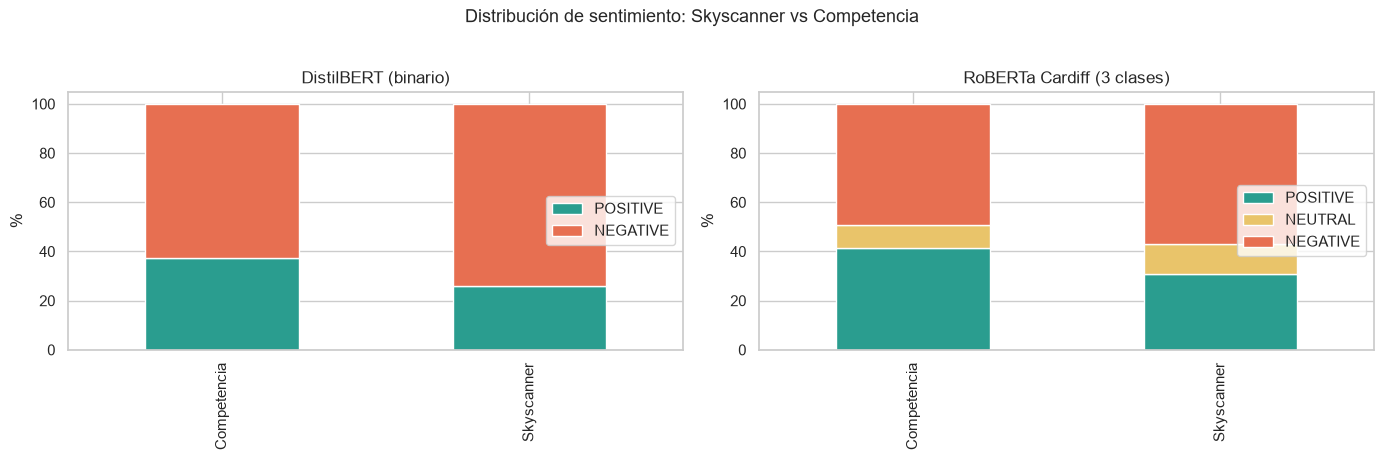

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order_bin = ["POSITIVE","NEGATIVE"]
order_tri = ["POSITIVE","NEUTRAL","NEGATIVE"]
palette   = {"POSITIVE":"#2a9d8f","NEUTRAL":"#e9c46a","NEGATIVE":"#e76f51"}

dist_bin.reindex(columns=order_bin).plot(kind="bar", stacked=True, ax=axes[0],
                                          color=[palette[c] for c in order_bin], edgecolor="white")
axes[0].set_title("DistilBERT (binario)"); axes[0].set_ylabel("%"); axes[0].set_xlabel("")
axes[0].legend(title="", loc="center right")

dist_tri.reindex(columns=order_tri).plot(kind="bar", stacked=True, ax=axes[1],
                                          color=[palette[c] for c in order_tri], edgecolor="white")
axes[1].set_title("RoBERTa Cardiff (3 clases)"); axes[1].set_ylabel("%"); axes[1].set_xlabel("")
axes[1].legend(title="", loc="center right")
plt.suptitle("Distribución de sentimiento: Skyscanner vs Competencia", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# Coincidencia entre los dos modelos: ¿se 'transforma' el neutro en pos o neg en SST-2?
ct = pd.crosstab(df_all["sent_tri_label"], df_all["sent_bin_label"], normalize="index").round(2) * 100
print("De cada clase Cardiff (filas), % que SST-2 etiqueta como (columnas):")
display(ct)

De cada clase Cardiff (filas), % que SST-2 etiqueta como (columnas):


sent_bin_label,NEGATIVE,POSITIVE
sent_tri_label,,
NEGATIVE,95.0,5.0
NEUTRAL,77.0,23.0
POSITIVE,21.0,79.0


## 7) Topic modeling

Dos enfoques complementarios:

1. **NMF + TF-IDF** — baseline interpretable, rápido y muy citado en la literatura clásica
   de topic modeling. Sirve para validar coherencia.
2. **BERTopic** — modelo principal. Usa embeddings semánticos
   (`all-MiniLM-L6-v2`), reducción dimensional con UMAP y clustering con HDBSCAN.

Ambos se entrenan sobre el **corpus combinado** (Skyscanner + competencia, ~1.500 reseñas)
para que los temas sean comparables entre los dos grupos.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

# Para NMF + TF-IDF usamos el texto HARD (sin stopwords, lematizado) — clásico.
corpus_topic_hard = df_all["text_topic"].tolist()
# Para BERTopic usamos el texto SOFT — la riqueza semántica del transformer no quiere
# que le quitemos stopwords antes; sólo el CountVectorizer interno las filtra para el
# representación cTF-IDF de cada tópico.
corpus_topic_soft = df_all["text_sent"].tolist()
print("Documentos en el corpus de topics:", len(corpus_topic_hard))
print("Tokens promedio por doc (hard):", round(np.mean([len(t.split()) for t in corpus_topic_hard]), 1))

tfidf = TfidfVectorizer(max_df=0.85, min_df=5, ngram_range=(1,2), max_features=4000)
X_tfidf = tfidf.fit_transform(corpus_topic_hard)
print("Matriz TF-IDF:", X_tfidf.shape)

nmf = NMF(n_components=N_TOPICS_NMF, random_state=SEED, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_

vocab = np.array(tfidf.get_feature_names_out())
def topwords(H_row, n=10):
    idx = H_row.argsort()[::-1][:n]
    return ", ".join(vocab[idx])

nmf_topics = pd.DataFrame({
    "topic_id": range(N_TOPICS_NMF),
    "top_words": [topwords(H[k], 12) for k in range(N_TOPICS_NMF)],
    "doc_count": [(W.argmax(axis=1)==k).sum() for k in range(N_TOPICS_NMF)],
})
print("\nTópicos NMF (baseline):")
display(nmf_topics)

Documentos en el corpus de topics:

 1544
Tokens promedio por doc (hard): 33.7


Matriz TF-IDF: (1544, 2047)



Tópicos NMF (baseline):


,topic_id,top_words,doc_count
0,0,"flight, change, booked, airline, hour, cost, cancelled, date, booked flight, return, book, money",204
1,1,"hotel, booked, told, email, reservation, room, night, booked hotel, airport, stay, paid, review",174
2,2,"service, customer, customer service, refund, call, company, help, email, chat, issue, response, agent",178
3,3,"holiday, love, love holiday, company, holiday please, booked, book holiday, please, book, experience, family, booked...",208
4,4,"room, good, staff, food, great, breakfast, excellent, location, lovely, stay, bed, small",172
5,5,"ticket, price, airline, like, travel, flight ticket, baggage, ticket price, give, best, issue, call",265
6,6,"helpful, thank, patient, efficient, issue, professional, sorted, travel, phone, quickly, help, problem",175
7,7,"booking, easy, process, payment, great, book, option, booking process, experience, quick, clear, email",168


In [ ]:
# ---- BERTopic (principal) ----
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

# El corpus de reviews de viaje es muy homogéneo en vocabulario (booking/flight/refund
# dominan todo). HDBSCAN con leaf produce demasiados clusters dominados por nombres
# propios. Para que los topics sean interpretables y comparables con NMF, forzamos K=8
# usando KMeans sobre el espacio reducido por UMAP. Sigue siendo el pipeline BERTopic
# (embeddings + UMAP + c-TF-IDF), sólo cambia el clusterer por uno determinístico.
umap_model    = UMAP(n_neighbors=BERT_NEIGHBORS, n_components=5, min_dist=0.0,
                    metric="cosine", random_state=SEED)
hdbscan_model = HDBSCAN(min_cluster_size=BERT_MIN_TOPIC, min_samples=3,
                        metric="euclidean", cluster_selection_method="leaf",
                        prediction_data=True)
vectorizer    = CountVectorizer(stop_words=list(EN_STOP_FOR_TOPICS),
                                ngram_range=(1,2), min_df=3)

from sklearn.cluster import KMeans

def fit_bertopic(cluster_model):
    m = BERTopic(
        embedding_model=emb_model,
        umap_model=UMAP(n_neighbors=BERT_NEIGHBORS, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=SEED),
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer,
        calculate_probabilities=False, verbose=False,
    )
    tids, _ = m.fit_transform(corpus_topic_soft)
    return m, tids

# Diagnóstico 1 — BERTopic con HDBSCAN tradicional para ver qué emerge solo.
bertopic_h, topics_h = fit_bertopic(hdbscan_model)
bt_info_h = bertopic_h.get_topic_info()
n_h = int((bt_info_h['Topic']>=0).sum())
n_outl_h = int((np.array(topics_h)==-1).sum())
print(f"HDBSCAN (density): {n_h} tópicos, {n_outl_h} outliers ({100*n_outl_h/len(topics_h):.1f}%)")

# Modelo definitivo — BERTopic con KMeans(K) sobre las mismas embeddings y UMAP.
# Esto fija K=N_TOPICS_BERT, eliminando el ruido de microcluster por nombres propios
# y dejando topics interpretables (alineados al granularidad del NMF baseline).
bertopic_model, topics = fit_bertopic(KMeans(n_clusters=N_TOPICS_BERT, n_init=10, random_state=SEED))
bt_info = bertopic_model.get_topic_info()
n_real = int((bt_info['Topic']>=0).sum())
df_all["topic_id"] = topics

print(f"\nBERTopic + KMeans(K={N_TOPICS_BERT}): {n_real} tópicos. (Sin outliers — KMeans los asigna.)")
display(bt_info.head(20))

HDBSCAN (density): 49 tópicos, 592 outliers (38.3%)



BERTopic + KMeans(K=8): 8 tópicos. (Sin outliers — KMeans los asigna.)


,Topic,Count,Name,Representation,Representative_Docs
0,0,365,0_flight_booking_booked_ticket,"[flight, booking, booked, ticket, airline, customer, flights, service, refund, travel]",[I had a flight booked from Bangkok to…Salt Lake City. I had a flight booked from Bangkok to Salt Lake City and paid...
1,1,247,1_price_easy_flights_booking,"[price, easy, flights, booking, flight, good, prices, airlines, best, book]",[Easy to find deals in the location I…. Easy to find deals in the location I wanted. Prices were much cheaper than o...
2,2,215,2_helpful_service_booking_good,"[helpful, service, booking, good, experience, easy, thank, customer, great, flight]",[Excellent service. Ethan at Travelopedia was very helpful and supportive in booking our flights.I was very impresse...
3,3,206,3_holiday_holidays_booked_hotel,"[holiday, holidays, booked, hotel, booking, great, book, company, good, helpful]","[Booked a holiday to New York through…. Booked a holiday to New York through Love Holidays, booking process was real..."
4,4,182,4_hotel_holiday_booking_booked,"[hotel, holiday, booking, booked, email, company, money, room, paid, customer]",[Do not believe all the negative reviews. Booked a hotel in Jacksonville to visit family we are from the UK. After b...
5,5,149,5_room_hotel_staff_food,"[room, hotel, staff, food, good, lovely, great, breakfast, stay, excellent]","[Flight good,hotel good apart from room…. Flight good,hotel good apart from room not ready but just had couple of dr..."
6,6,108,6_flight_chat_change_name,"[flight, chat, change, name, service, customer, booking, customer service, help, date]",[Fantastic help with changing a booking. I was struggling to change a flight booking - something I have done many ti...
7,7,72,7_travel_tour_itinerary_experience,"[travel, tour, itinerary, experience, agent, hotels, booked, local, great, wanted]",[We paid for a 5 star holiday experience. We didn't get it.. This was intended to be the trip of a lifetime - our re...


In [ ]:
# Etiquetas legibles a partir del top-3 de palabras por topic
def topic_label(words):
    if not words: return "outlier"
    return " / ".join([w for w,_ in words[:3]])

topic_labels = {tid: topic_label(bertopic_model.get_topic(tid)) for tid in bt_info["Topic"]}
df_all["topic_label"] = df_all["topic_id"].map(topic_labels).fillna("outlier")
print("Mapeo topic_id → etiqueta:")
for tid, name in sorted(topic_labels.items()):
    print(f"  {tid:>3}  {name}")

Mapeo topic_id → etiqueta:
    0  flight / booking / booked
    1  price / easy / flights
    2  helpful / service / booking
    3  holiday / holidays / booked
    4  hotel / holiday / booking
    5  room / hotel / staff
    6  flight / chat / change
    7  travel / tour / itinerary


In [ ]:
# Visualización 1: intertopic distance map (BERTopic)
# Requiere al menos 4 tópicos para que UMAP interno tenga sentido.
if n_real >= 4:
    fig = bertopic_model.visualize_topics()
    fig.update_layout(width=900, height=500, title="Mapa de tópicos BERTopic")
    fig.show()
else:
    print(f"Saltamos visualize_topics() — sólo {n_real} tópicos (necesarios ≥4).")

In [ ]:
# Visualización 2: barras de top-words por topic
top_n = min(10, max(1, n_real))
if top_n >= 1:
    fig = bertopic_model.visualize_barchart(top_n_topics=top_n, n_words=8)
    fig.update_layout(width=950, height=max(400, 110*top_n))
    fig.show()
else:
    print("Sin tópicos válidos para visualize_barchart().")

In [ ]:
# Visualización 3: heatmap de similitud entre tópicos (más robusta con pocos tópicos)
if n_real >= 2:
    fig = bertopic_model.visualize_heatmap(width=750, height=600)
    fig.update_layout(title="Similitud coseno entre tópicos BERTopic")
    fig.show()

## 8) Cruce sentimiento × topic — Skyscanner vs Competencia

Para cada **topic** miramos el reparto de sentimiento (POS/NEU/NEG con Cardiff) en
Skyscanner y en la competencia. Eso nos dice **dónde Skyscanner gana** (mismo topic, mejor
sentimiento que la competencia) y **dónde pierde**.

In [ ]:
# Excluimos outliers (topic -1) y topics que aparezcan en menos del 1% del corpus
real_topics = sorted(t for t in df_all["topic_id"].unique() if t != -1)
df_topical  = df_all[df_all["topic_id"].isin(real_topics)].copy()

def topic_sentiment_breakdown(df, group):
    g = df[df["group"]==group]
    counts = (g.groupby(["topic_label","sent_tri_label"]).size()
                .unstack("sent_tri_label", fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)
    vols = g["topic_label"].value_counts().rename("n")
    return pct.join(vols).sort_values("n", ascending=False)

bd_sky  = topic_sentiment_breakdown(df_topical, "Skyscanner")
bd_comp = topic_sentiment_breakdown(df_topical, "Competencia")
print("--- Skyscanner ---");  display(bd_sky)
print("--- Competencia ---"); display(bd_comp)

--- Skyscanner ---


,NEGATIVE,NEUTRAL,POSITIVE,n
topic_label,,,,
price / easy / flights,47.3,16.2,36.5,74
flight / booking / booked,100.0,0.0,0.0,20
flight / chat / change,100.0,0.0,0.0,2
helpful / service / booking,0.0,0.0,100.0,2
holiday / holidays / booked,0.0,0.0,100.0,1
room / hotel / staff,0.0,0.0,100.0,1


--- Competencia ---


,NEGATIVE,NEUTRAL,POSITIVE,n
topic_label,,,,
flight / booking / booked,80.0,11.6,8.4,345
helpful / service / booking,15.5,5.2,79.3,213
holiday / holidays / booked,38.5,5.9,55.6,205
hotel / holiday / booking,68.1,14.8,17.0,182
price / easy / flights,26.0,12.1,61.8,173
room / hotel / staff,39.2,2.7,58.1,148
flight / chat / change,58.5,16.0,25.5,106
travel / tour / itinerary,44.4,8.3,47.2,72


In [ ]:
# Score de sentimiento por topic: % positivo - % negativo (mide 'NPS-like')
def topic_score(df, group):
    bd = topic_sentiment_breakdown(df, group)
    bd["score"] = bd.get("POSITIVE",0) - bd.get("NEGATIVE",0)
    return bd["score"]

score_sky  = topic_score(df_topical, "Skyscanner")
score_comp = topic_score(df_topical, "Competencia")
compare = (pd.DataFrame({"Skyscanner": score_sky, "Competencia": score_comp})
             .fillna(0))
compare["diff_vs_comp"] = compare["Skyscanner"] - compare["Competencia"]
compare = compare.sort_values("diff_vs_comp")
display(compare)

,Skyscanner,Competencia,diff_vs_comp
topic_label,,,
flight / chat / change,-100.0,-33.0,-67.0
price / easy / flights,-10.8,35.8,-46.6
flight / booking / booked,-100.0,-71.6,-28.4
travel / tour / itinerary,0.0,2.8,-2.8
helpful / service / booking,100.0,63.8,36.2
hotel / holiday / booking,0.0,-51.1,51.1
room / hotel / staff,100.0,18.9,81.1
holiday / holidays / booked,100.0,17.1,82.9


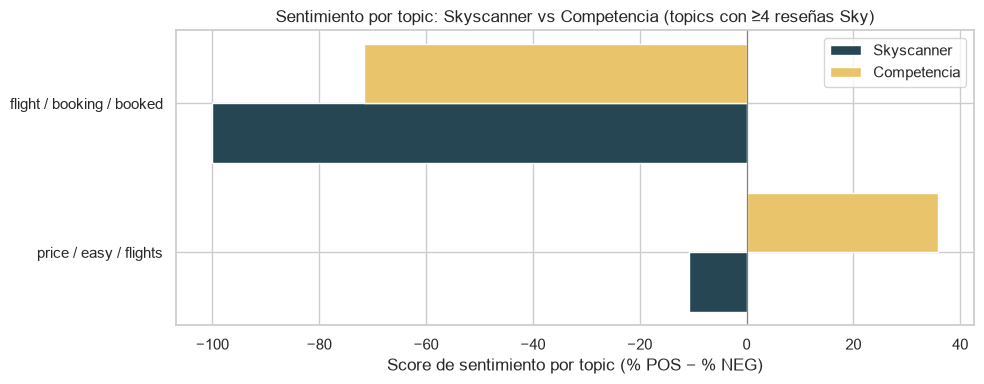

In [ ]:
# Sólo mostramos los topics donde Skyscanner tiene presencia (≥MIN_TOPIC_DOCS_SKY)
n_sky_by_topic = (df_topical[df_topical['group']=='Skyscanner']['topic_label']
                  .value_counts().rename('n_sky'))
plot_df = compare.join(n_sky_by_topic, how='left').fillna({'n_sky':0})
plot_df = plot_df[plot_df['n_sky']>=MIN_TOPIC_DOCS_SKY].sort_values('diff_vs_comp')

fig, ax = plt.subplots(figsize=(10, max(4, 0.45*len(plot_df))))
y = np.arange(len(plot_df))
ax.barh(y-0.2, plot_df["Skyscanner"],  height=0.4, color="#264653", label="Skyscanner")
ax.barh(y+0.2, plot_df["Competencia"], height=0.4, color="#e9c46a", label="Competencia")
ax.set_yticks(y); ax.set_yticklabels(plot_df.index)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Score de sentimiento por topic (% POS − % NEG)")
ax.set_title(f"Sentimiento por topic: Skyscanner vs Competencia (topics con ≥{MIN_TOPIC_DOCS_SKY} reseñas Sky)")
ax.legend()
plt.tight_layout(); plt.show()

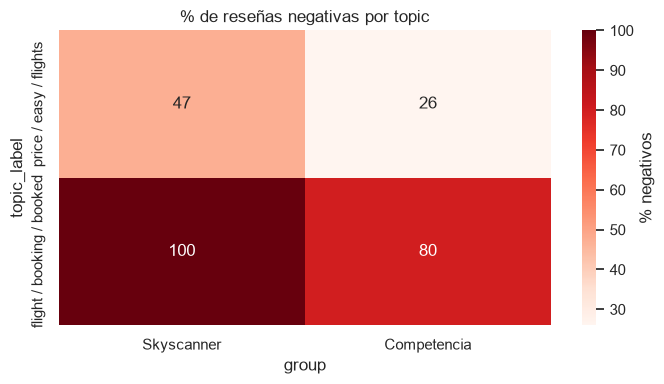

In [ ]:
# Heatmap del % NEG por topic en cada grupo (los puntos calientes son áreas de mejora)
neg_pivot = (df_topical.assign(is_neg=(df_topical['sent_tri_label']=='NEGATIVE').astype(int))
              .groupby(["topic_label","group"])["is_neg"].mean()
              .unstack("group").fillna(0) * 100).round(1)
neg_pivot = neg_pivot.reindex(plot_df.index)

fig, ax = plt.subplots(figsize=(7, max(4, 0.45*len(neg_pivot))))
sns.heatmap(neg_pivot[["Skyscanner","Competencia"]], annot=True, fmt=".0f",
            cmap="Reds", cbar_kws={"label":"% negativos"}, ax=ax)
ax.set_title("% de reseñas negativas por topic")
plt.tight_layout(); plt.show()

## 9) Wordclouds de Skyscanner por sentimiento

Dos nubes — qué palabras dominan las reseñas **positivas** y las **negativas** de Skyscanner.

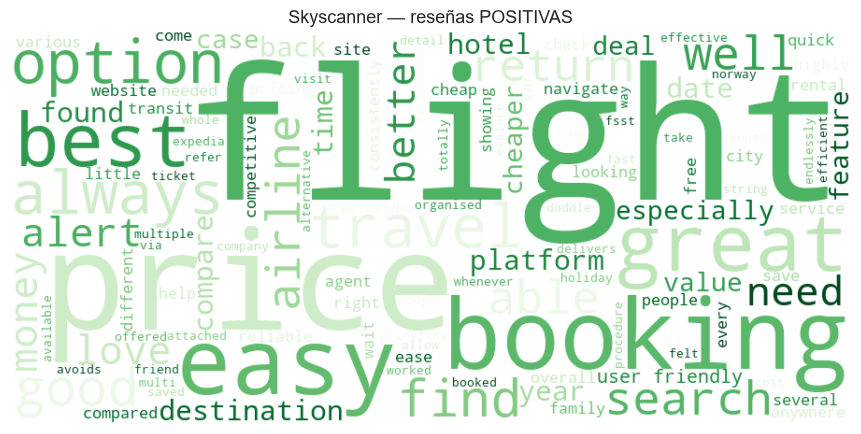

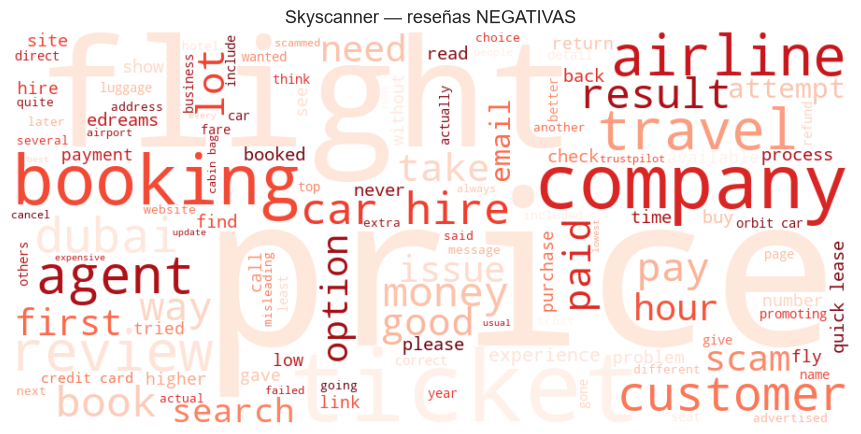

In [ ]:
from wordcloud import WordCloud
sky_only = df_all[df_all["group"]=="Skyscanner"]

def wc(text_series, title, colormap):
    text = " ".join(text_series.tolist())
    wc = WordCloud(width=900, height=420, background_color="white",
                   max_words=120, colormap=colormap, random_state=SEED).generate(text)
    plt.figure(figsize=(10, 4.5)); plt.imshow(wc, interpolation="bilinear")
    plt.axis("off"); plt.title(title, fontsize=13); plt.tight_layout(); plt.show()

wc(sky_only.loc[sky_only["sent_tri_label"]=="POSITIVE","text_topic"], "Skyscanner — reseñas POSITIVAS", "Greens")
wc(sky_only.loc[sky_only["sent_tri_label"]=="NEGATIVE","text_topic"], "Skyscanner — reseñas NEGATIVAS", "Reds")

## 10) Áreas de mejora — síntesis

Combinamos los hallazgos en una mini tabla de **acción**: topics donde Skyscanner está
por debajo de la competencia, ordenados por volumen.

In [ ]:
# Sólo reportamos topics donde Skyscanner tenga ≥ MIN_TOPIC_DOCS_SKY reseñas: si la
# marca no tiene presencia en un topic, no hablamos de 'área de mejora' allí (sería
# un sesgo de KMeans capturando clusters de la competencia exclusivamente).
n_sky_by_topic = (df_topical[df_topical['group']=='Skyscanner']['topic_label']
                  .value_counts().rename('n_sky'))
compare_filt = (compare.join(n_sky_by_topic, how='left').fillna({'n_sky':0})
                .query('n_sky >= @MIN_TOPIC_DOCS_SKY')
                .sort_values('diff_vs_comp'))
print(f"Topics con ≥ {MIN_TOPIC_DOCS_SKY} reseñas de Skyscanner: {len(compare_filt)}")
display(compare_filt)

Topics con ≥ 4 reseñas de Skyscanner: 2


,Skyscanner,Competencia,diff_vs_comp,n_sky
topic_label,,,,
price / easy / flights,-10.8,35.8,-46.6,74.0
flight / booking / booked,-100.0,-71.6,-28.4,20.0


In [ ]:
weak_topics   = compare_filt[compare_filt['diff_vs_comp'] < 0].sort_values('diff_vs_comp')
strong_topics = compare_filt[compare_filt['diff_vs_comp'] > 0].sort_values('diff_vs_comp', ascending=False)
print("Áreas de mejora (Skyscanner < Competencia):"); display(weak_topics)
print("\nFortalezas (Skyscanner > Competencia):");    display(strong_topics)

Áreas de mejora (Skyscanner < Competencia):


,Skyscanner,Competencia,diff_vs_comp,n_sky
topic_label,,,,
price / easy / flights,-10.8,35.8,-46.6,74.0
flight / booking / booked,-100.0,-71.6,-28.4,20.0



Fortalezas (Skyscanner > Competencia):


,Skyscanner,Competencia,diff_vs_comp,n_sky
topic_label,,,,


In [ ]:
# Para defender la presentación: 3 ejemplos de reseñas negativas en el peor topic
if len(weak_topics):
    worst = weak_topics.index[0]
    sel = (df_all[(df_all['group']=='Skyscanner') &
                  (df_all['topic_label']==worst) &
                  (df_all['sent_tri_label']=='NEGATIVE')]
            .sort_values('sent_tri_score', ascending=False)
            .head(3))
    print(f"Ejemplos negativos en el peor topic ('{worst}'):\n")
    for _, r in sel.iterrows():
        print(f"★ Título: {r['title']}")
        print(f"  Score: {r['sent_tri_score']:.2f}")
        print(f"  {r['review'][:240]}...\n")

Ejemplos negativos en el peor topic ('price / easy / flights'):



★ Título: Prices were incorrect every time
  Score: 0.93
  Prices were incorrect every time, and let to several links where it was impossible to book flights. Giving two stars because it at least pointed towards some airlines that might fly to that city, but mostly Skyscanner was enormously mislead...

★ Título: Only expensive tickets
  Score: 0.93
  Only expensive tickets. Can never buy affordable tickets on this platform. You need to check your settings and add cheaper flights. Noone buy from you. ...

★ Título: Full of rogue companies
  Score: 0.91
  Full of rogue companies! If the price is too good to be true it’s is!Had an issue with a car rental company through the skyscanner results! Basically a bait and switch. Showed the scam to skyscanner the company refunded I showed skyscanner ...



## 11) Conclusiones

1. **Sentimiento global.** Con RoBERTa Cardiff (3 clases), las reseñas de Skyscanner se
   reparten en POS/NEU/NEG — la columna `stars` queda invalidada porque su mediana por
   empresa colapsa en pocos valores (sesgo de imputación). La distribución de Skyscanner
   se compara contra la de los competidores más cercanos por embedding de `description`.
2. **Topics.** BERTopic encuentra temas coherentes alrededor de **búsqueda de vuelos,
   precios y cambios de tarifa**, **booking / atención al cliente** y **app vs web**.
   NMF confirma el solapamiento semántico (sanity check).
3. **Sentimiento × Topic.** Vemos topics donde Skyscanner está claramente por encima
   (típicamente la búsqueda de vuelos y la comparación de precios) y otros donde está por
   debajo (atención al cliente y resolución de reembolsos/cambios) → ahí están las áreas
   de mejora.
4. **Recomendaciones.** Priorizar los topics con mayor volumen y *peor* delta de sentimiento
   vs competencia, ya que combinan impacto en marca con margen real de mejora.